# Classification #

In [1]:
from pandas import read_csv
import matplotlib.pyplot as plt
import numpy as np
from sklearn import preprocessing

In [2]:
df = read_csv("../../datasets/Customer_Churn.csv")
df.head()

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
0,8,0,38,0,4370,71,5,17,3,1,1,30,197.640,0
1,0,0,39,0,318,5,7,4,2,1,2,25,46.035,0
2,10,0,37,0,2453,60,359,24,3,1,1,30,1536.520,0
3,10,0,38,0,4198,66,1,35,1,1,1,15,240.020,0
4,3,0,38,0,2393,58,2,33,1,1,1,15,145.805,0


### Let's look at the data: ###

In [3]:
df['Churn'].value_counts()

Churn
0    2655
1     495
Name: count, dtype: int64

array([[<Axes: title={'center': 'Seconds of Use'}>]], dtype=object)

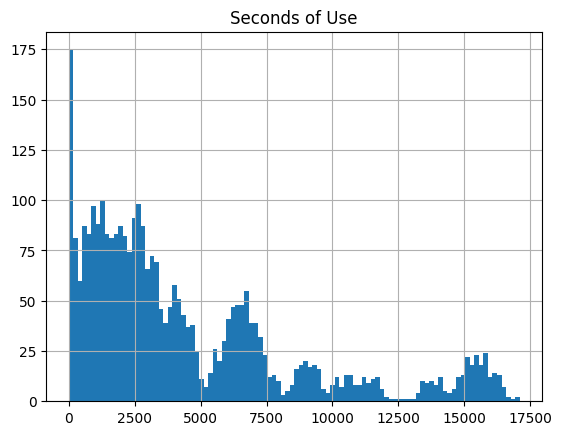

In [4]:
df.hist(column='Seconds of Use', bins=100)

### We will classify the data by users who are happy (churn=0) and unhappy (churn=1) ###
### So the data is separated to the X part and Y part ( which is churn ) ###

In [5]:
df.columns

Index(['Call  Failure', 'Complains', 'Subscription  Length', 'Charge  Amount',
       'Seconds of Use', 'Frequency of use', 'Frequency of SMS',
       'Distinct Called Numbers', 'Age Group', 'Tariff Plan', 'Status', 'Age',
       'Customer Value', 'Churn'],
      dtype='object')

In [6]:
X = df[['Call  Failure', 'Complains', 'Subscription  Length', 'Charge  Amount',
       'Seconds of Use', 'Frequency of use', 'Frequency of SMS',
       'Distinct Called Numbers', 'Age Group', 'Tariff Plan', 'Status', 'Age',
       'Customer Value']].values
X

array([[8.00000e+00, 0.00000e+00, 3.80000e+01, ..., 1.00000e+00,
        3.00000e+01, 1.97640e+02],
       [0.00000e+00, 0.00000e+00, 3.90000e+01, ..., 2.00000e+00,
        2.50000e+01, 4.60350e+01],
       [1.00000e+01, 0.00000e+00, 3.70000e+01, ..., 1.00000e+00,
        3.00000e+01, 1.53652e+03],
       ...,
       [1.30000e+01, 0.00000e+00, 1.80000e+01, ..., 1.00000e+00,
        3.00000e+01, 2.80320e+02],
       [7.00000e+00, 0.00000e+00, 1.10000e+01, ..., 1.00000e+00,
        3.00000e+01, 1.07764e+03],
       [8.00000e+00, 1.00000e+00, 1.10000e+01, ..., 1.00000e+00,
        3.00000e+01, 1.00680e+02]])

In [7]:
Y = df['Churn'].values
Y

array([0, 0, 0, ..., 0, 0, 1], dtype=int64)

### It's time to normalize the data, the mean values will be counted as 0 ###
### Values after them will be a number between 0 and 1 ###
### Values before them will be a number between -1 and 0 ###

In [8]:
scaler = preprocessing.StandardScaler().fit(X)
X = scaler.transform(X.astype(float))
print(X[0:5])

[[ 0.05122913 -0.2878304   0.63672633 -0.61996205 -0.02441119  0.02681625
  -0.60751272 -0.37815805  0.19494132 -0.29040893 -0.57466206 -0.11307444
  -0.52875851]
 [-1.05028466 -0.2878304   0.75338358 -0.61996205 -0.98980697 -1.12292553
  -0.58969054 -1.1333308  -0.92561556 -0.29040893  1.74015315 -0.67934551
  -0.82203616]
 [ 0.32660758 -0.2878304   0.52006909 -0.61996205 -0.48113965 -0.16480738
   2.54701243  0.02847342  0.19494132 -0.29040893 -0.57466206 -0.11307444
   2.0612852 ]
 [ 0.32660758 -0.2878304   0.63672633 -0.61996205 -0.06539048 -0.0602854
  -0.64315707  0.66746575 -2.04617244 -0.29040893 -0.57466206 -1.81188763
  -0.44677503]
 [-0.63721699 -0.2878304   0.63672633 -0.61996205 -0.49543475 -0.19964804
  -0.63424598  0.55128532 -2.04617244 -0.29040893 -0.57466206 -1.81188763
  -0.62903256]]


### As we would separate our data to train data and test data, we'll do the same here. ###
### The train_test_split is the right function for it. ###
### test_size is the ratio for training data and testing data ###
### random_state works as a kind of seed and helps us get the same combination each time we run the code.###

In [9]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test = train_test_split(X, Y, test_size=0.2, random_state=3)
print("train data: ", X_train.shape, Y_train.shape)
print("test data: ", X_test.shape, Y_test.shape)

train data:  (2520, 13) (2520,)
test data:  (630, 13) (630,)


In [10]:
from sklearn.neighbors import KNeighborsClassifier

## KNN uses K nearest neighbors to the data to predict the situation. ##
## Let's start with k=4 ##

In [11]:
k = 11
neigh = KNeighborsClassifier(n_neighbors=k)
neigh.fit(X_train, Y_train)
neigh  # our model!

KNeighborsClassifier(n_neighbors=11)

### Let's take a look at what we've done! ###

In [12]:
yhat = neigh.predict(X_test)
print("Real data: ", Y[0:35])
print("Prediction: ", yhat[0:35])

Real data:  [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 1 0 1 0 1 1 1 0 0 1 0 0 0]
Prediction:  [0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0]


### A more precisely look ###

In [13]:
from sklearn import metrics
print("train set accuracy: ", metrics.accuracy_score(Y_train, neigh.predict(X_train)))
print("test set accuracy: ", metrics.accuracy_score(Y_test, yhat))

print("f1_score: ", metrics.f1_score(Y_test, yhat))

train set accuracy:  0.9519841269841269
test set accuracy:  0.9507936507936507
f1_score:  0.8248587570621468


In [14]:
from pprint import pprint

Ks = 15

mean_acc = np.zeros((Ks-1))
fscores = np.zeros((Ks-1))

for n in range(1, k):
    neigh = KNeighborsClassifier(n_neighbors=n).fit(X_train, Y_train)
    yhat = neigh.predict(X_test)
    mean_acc[n-1]= metrics.accuracy_score(Y_test, yhat)
    fscores[n-1] = metrics.f1_score(Y_test, yhat)


pprint(list(zip(mean_acc, fscores)))
# Best K would be 3

[(0.9523809523809523, 0.8351648351648352),
 (0.9571428571428572, 0.8363636363636363),
 (0.9571428571428572, 0.8556149732620321),
 (0.953968253968254, 0.8284023668639053),
 (0.9507936507936507, 0.8268156424581006),
 (0.9507936507936507, 0.8121212121212121),
 (0.9444444444444444, 0.8),
 (0.946031746031746, 0.7976190476190477),
 (0.9428571428571428, 0.7931034482758621),
 (0.9428571428571428, 0.788235294117647),
 (0.0, 0.0),
 (0.0, 0.0),
 (0.0, 0.0),
 (0.0, 0.0)]


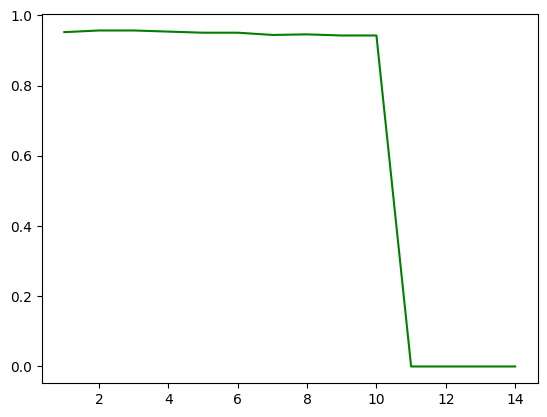

In [15]:
plt.plot(range(1, Ks), mean_acc, 'g')


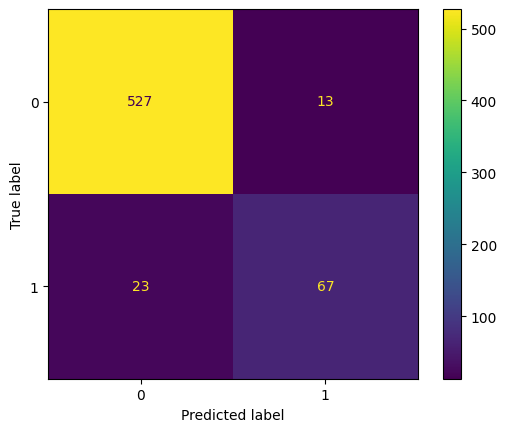

In [18]:
neigh = KNeighborsClassifier(n_neighbors=n).fit(X_train, Y_train)
yhat = neigh.predict(X_test)

cm = metrics.confusion_matrix(Y_test, yhat)
disp = metrics.ConfusionMatrixDisplay(cm)
disp.plot()